<a href="https://colab.research.google.com/github/Deepayanbasu07/SAR-Target-Classification-Using-Deep-Learning/blob/main/SAR_Target_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.fft import fft2, fftshift, ifft2
import seaborn as sns
from tqdm import tqdm

In [18]:
gpu_available = tf.config.list_physical_devices('GPU')
if gpu_available:
    print("GPU is available.")
else:
    print("GPU is not available.")

GPU is available.


# Set random seeds for reproducibility


In [19]:
np.random.seed(42)
tf.random.set_seed(42)

# 1. Dataset Configuration

In [20]:
DATASET_PATH = Path('/content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data')
VEHICLE_CLASSES = ['2S1', 'BRDM_2', 'BTR_60', 'D7', 'SLICY', 'T62', 'ZIL131', 'ZSU_23_4']
IMG_SIZE = 128  # MSTAR original size
BATCH_SIZE = 32
EPOCHS = 100

# 2. SAR-Specific Functions

In [21]:
def add_speckle_noise(image, L=1):
    """Add gamma-distributed speckle noise as per SAR characteristics"""
    noise = np.random.gamma(shape=L, scale=1/L, size=image.shape)
    return np.clip(image * noise, 0, 1)

def amplitude_spectrum_analysis(kernel, th_r=0.7, R=70):
    """Amplitude spectrum analysis for despeckling layers (TDP-SAR)"""
    kernel_spectrum = np.abs(fftshift(fft2(kernel)))
    binary_spectrum = (kernel_spectrum > np.mean(kernel_spectrum)).astype(int)

    # Create circular mask for frequency bands
    y, x = np.ogrid[-kernel.shape[0]//2:kernel.shape[0]//2,
                    -kernel.shape[1]//2:kernel.shape[1]//2]
    mask = x*x + y*y <= R*R

    P_l = np.sum(binary_spectrum * mask)
    P_h = np.sum(binary_spectrum * ~mask)

    r = P_h / (P_l + 1e-8)  # Avoid division by zero
    return r > th_r

def phase_spectrum_analysis(kernel, th_c=0.5):
    """Phase spectrum analysis for recognition layers (TDP-SAR)"""
    # Create test image (ideal target)
    test_img = np.zeros((IMG_SIZE, IMG_SIZE))
    cv2.rectangle(test_img, (30, 30), (98, 98), 1, -1)

    # Phase reconstruction
    phase_original = np.angle(fft2(test_img))
    phase_kernel = np.angle(fft2(kernel, s=(IMG_SIZE, IMG_SIZE)))

    # Combined phase reconstruction
    combined_phase = phase_original + phase_kernel
    reconstructed = np.abs(ifft2(np.exp(1j * combined_phase)))

    # Correlation coefficient
    corr = np.corrcoef(test_img.flatten(), reconstructed.flatten())[0, 1]
    return corr > th_c

# 3. Data Loading and Preparation


In [27]:
def load_dataset():
    """Load and preprocess MSTAR dataset with recursive search"""
    X, y = [], []
    class_map = {cls: idx for idx, cls in enumerate(VEHICLE_CLASSES)}

    # Recursive search for images
    for cls in VEHICLE_CLASSES:
        # Use *.* to match any file extension and filter later
        image_paths = list(DATASET_PATH.glob(f'**/{cls}/*.*'))
        print(f"Found {len(image_paths)} potential images for class {cls}")

        for img_path in image_paths:
            # Read and preprocess image
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img.astype('float32') / 255.0  # Normalize
                X.append(img)
                y.append(class_map[cls])
            else:
                 print(f"Could not load image: {img_path}")

    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y

# 4. J-CNN Model Architecture (Dual-Task)

In [23]:
def build_jcnn_model(input_shape, num_classes):
    """Joint Despeckling-Recognition CNN with TDP-SAR compatible architecture"""
    inputs = layers.Input(shape=input_shape)

    # ------ Despeckling Branch ------
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(x)

    despeckled_output = layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid',
                                      name='despeckled_output')(x)

    # ------ Recognition Branch ------
    y = layers.Conv2D(6, (9, 9), padding='same', activation='relu')(despeckled_output)
    y = layers.Conv2D(36, (9, 9), padding='same', activation='relu')(y)
    y = layers.Conv2D(36, (9, 9), padding='same', activation='relu')(y)
    y = layers.GlobalAveragePooling2D()(y)
    y = layers.Dense(128, activation='relu')(y)
    class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(y)

    return models.Model(inputs=inputs, outputs=[despeckled_output, class_output])

# 5. TDP-SAR Pruning Implementation

In [24]:
def tdp_sar_pruning(model, th_r=0.7, th_c=0.5):
    """Task-Driven Pruning for SAR models (TDP-SAR)"""
    pruned_model = tf.keras.models.clone_model(model)
    pruned_model.set_weights(model.get_weights())

    # Identify layer types
    despeckling_layers = [l for l in pruned_model.layers if 'conv2d' in l.name and int(l.name.split('_')[1]) < 6]
    recognition_layers = [l for l in pruned_model.layers if 'conv2d' in l.name and int(l.name.split('_')[1]) >= 6]

    # Prune despeckling layers (amplitude analysis)
    for layer in despeckling_layers:
        weights = layer.get_weights()
        if len(weights) == 0:
            continue

        kernels = weights[0]
        new_kernels = []
        kept_indices = []

        for i in range(kernels.shape[-1]):
            kernel = kernels[:, :, 0, i]  # For grayscale
            if not amplitude_spectrum_analysis(kernel, th_r):
                new_kernels.append(kernels[:, :, :, i])
                kept_indices.append(i)

        if len(kept_indices) > 0:
            new_kernels = np.stack(new_kernels, axis=-1)
            new_biases = weights[1][kept_indices] if len(weights) > 1 else None

            # Update layer config
            layer_config = layer.get_config()
            layer_config['filters'] = len(kept_indices)
            new_layer = type(layer).from_config(layer_config)

            # Set new weights
            if new_biases is not None:
                new_layer.set_weights([new_kernels, new_biases])
            else:
                new_layer.set_weights([new_kernels])

            # Replace layer in model
            model = replace_layer(model, layer, new_layer)

    # Prune recognition layers (phase analysis)
    for layer in recognition_layers:
        weights = layer.get_weights()
        if len(weights) == 0:
            continue

        kernels = weights[0]
        new_kernels = []
        kept_indices = []

        for i in range(kernels.shape[-1]):
            kernel = kernels[:, :, 0, i]  # For grayscale
            if not phase_spectrum_analysis(kernel, th_c):
                new_kernels.append(kernels[:, :, :, i])
                kept_indices.append(i)

        if len(kept_indices) > 0:
            new_kernels = np.stack(new_kernels, axis=-1)
            new_biases = weights[1][kept_indices] if len(weights) > 1 else None

            # Update layer config
            layer_config = layer.get_config()
            layer_config['filters'] = len(kept_indices)
            new_layer = type(layer).from_config(layer_config)

            # Set new weights
            if new_biases is not None:
                new_layer.set_weights([new_kernels, new_biases])
            else:
                new_layer.set_weights([new_kernels])

            # Replace layer in model
            model = replace_layer(model, layer, new_layer)

    return model

def replace_layer(model, old_layer, new_layer):
    """Utility function to replace layers in a model"""
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            replace_layer(layer, old_layer, new_layer)
        else:
            for i, node in enumerate(layer._outbound_nodes):
                if node.outbound_layer == old_layer:
                    layer._outbound_nodes[i].outbound_layer = new_layer
    return model


# 6. Training and Evaluation

Loading dataset...
Found 1168 potential images for class 2S1
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/15_DEG/COL2/SCENE1/2S1/TARGET.HTM
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/45_DEG/COL2/SCENE1/2S1/TARGET.HTM
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/17_DEG/COL2/SCENE1/2S1/TARGET.HTM
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/30_DEG/COL2/SCENE1/2S1/TARGET.HTM
Found 1421 potential images for class BRDM_2
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/15_DEG/COL2/SCENE1/BRDM_2/TARGET.HTM
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/45_DEG/COL2/SCENE1/BRDM_2/TARGET.HTM
Could not load image: /content/drive/MyDrive/SAR Target Classification/MSTAR_TargetData/Data/45_DEG/COL2/SCENE3/BRDM_2/TARGET.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 6)    │           492 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 36)   │        17,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 36)   │       105,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 36)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,804 (503.14 KB)

 Trainable params: 128,804 (503.14 KB)

 Non-trainable params: 0 (0.00 B)

Training CNN model...
Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 52s 191ms/step - accuracy: 0.3054 - loss: 1.8265 - val_accuracy: 0.4831 - val_loss: 1.2652 - learning_rate: 0.0010
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 61s 143ms/step - accuracy: 0.5395 - loss: 1.1920 - val_accuracy: 0.5859 - val_loss: 1.1118 - learning_rate: 0.0010
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.6054 - loss: 1.0283 - val_accuracy: 0.6035 - val_loss: 1.0628 - learning_rate: 0.0010
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.6325 - loss: 0.9528 - val_accuracy: 0.6982 - val_loss: 0.8420 - learning_rate: 0.0010
Epoch 5/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.6459 - loss: 0.9278 - val_accuracy: 0.6346 - val_loss: 0.9266 - learning_rate: 0.0010
Epoch 6/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.6462 - loss: 0.9021 - val_accuracy: 0.7145 - val_loss: 0.7793 - learning_rate: 0.0010
Epoch 7/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 3

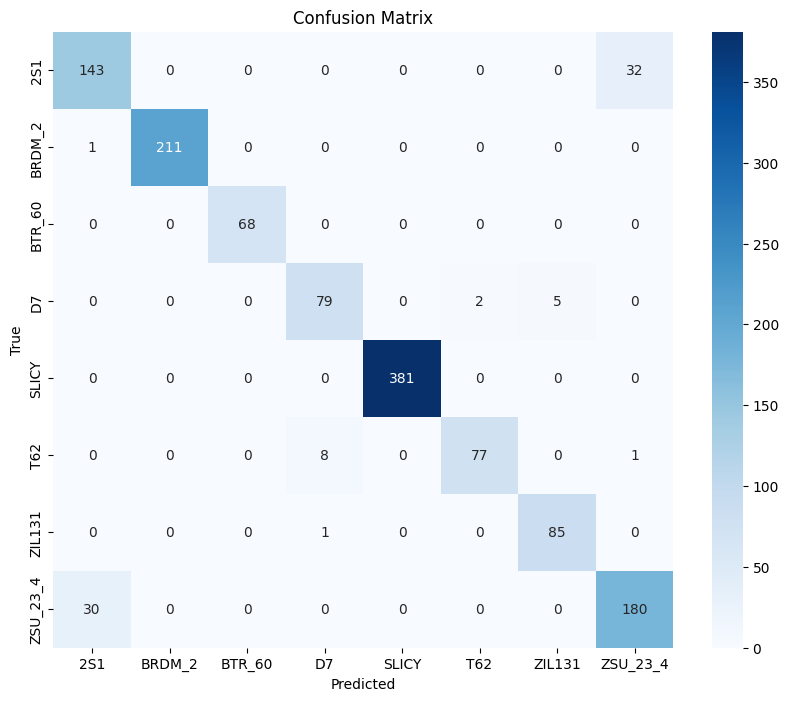

In [28]:
def main():
    print("Loading dataset...")
    X, y = load_dataset()
    X = np.expand_dims(X, axis=-1)


    print(f"Dataset shape: {X.shape}")

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

    # Build CNN model for classification only
    input_shape = (IMG_SIZE, IMG_SIZE, 1)
    num_classes = len(VEHICLE_CLASSES)

    # Simplified model for classification based on the recognition branch architecture
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(6, (9, 9), padding='same', activation='relu'),
        layers.Conv2D(36, (9, 9), padding='same', activation='relu'),
        layers.Conv2D(36, (9, 9), padding='same', activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile for classification
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    model.summary()

    # Train model
    print("Training CNN model...")
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-7)
        ]
    )

    # Evaluate
    print("\nEvaluation:")
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"Test accuracy: {test_acc:.4f}")

    # Classification report and confusion matrix
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=VEHICLE_CLASSES))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=VEHICLE_CLASSES, yticklabels=VEHICLE_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


if __name__ == "__main__":
    main()